In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("./deeplearning.mplstyle")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
%matplotlib widget

from matplotlib.widgets import Slider
from jupyter_utils_common import dlc
from jupyter_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [4]:
def my_softmax(z):
    e_z = np.exp(z)
    sm = e_z / np.sum(e_z)
    return sm

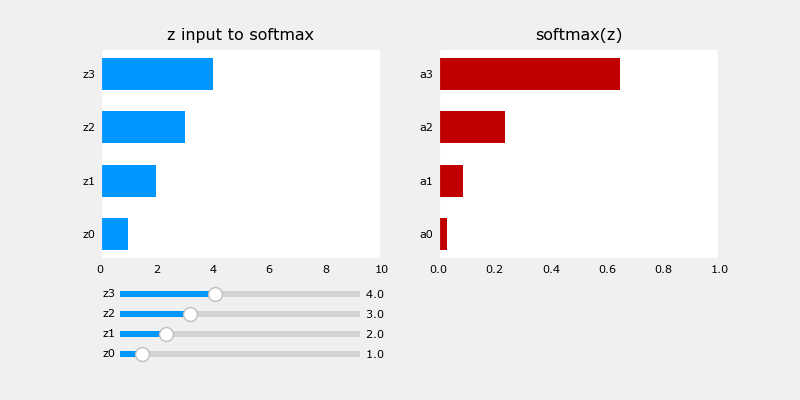

In [5]:
plt.close("all")
plt_softmax(my_softmax)

In [6]:
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
x_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0, random_state=30)

In [7]:
model = Sequential([
    Dense(25, activation="relu"),
    Dense(15, activation="relu"),
    Dense(4, activation="softmax")
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001)
)

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 1.2406 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 0.5087
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.2616
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.1531
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - loss: 0.1040
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 0.0795
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 0.0656
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 0.0568
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 0.0510
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 0.0459


In [8]:
p_nonpreferred = model.predict(x_train)
print(p_nonpreferred[:2])
print("Largest Value", np.max(p_nonpreferred), "Smallest Value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step
[[1.58e-02 6.06e-03 9.67e-01 1.14e-02]
 [9.87e-01 1.32e-02 6.07e-05 2.07e-07]]
Largest Value 0.999997 Smallest Value 7.694966e-15


In [10]:
preferred_model = Sequential([
    Dense(25, activation="relu"),
    Dense(15, activation="relu"),
    Dense(4, activation="linear")
])

preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001)
)

preferred_model.fit(x_train, y_train, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 1.1230 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.4529
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.2242
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.1347
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 0.0958
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.0762
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step - loss: 0.0646
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 0.0568
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - loss: 0.0516
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.0480


In [11]:
p_preferred = preferred_model.predict(x_train)
print(f"Two Example Outpute Vecotrs:\n {p_preferred[:2]}")
print("Largets Value", np.max(p_preferred), "Smallest Value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step
Two Example Outpute Vecotrs:
 [[-1.72 -2.31  2.79 -0.41]
 [ 5.62  1.05 -3.61 -5.54]]
Largets Value 10.754992 Smallest Value -9.622063


In [12]:
sm_preferred = tf.nn.softmax(p_preferred).numpy()
print(f"Two Example Output Vectors: {sm_preferred[:2]}")
print("Largetst Value", np.max(sm_preferred), "Smallest Value", np.min(sm_preferred))

Two Example Output Vectors: [[1.03e-02 5.75e-03 9.45e-01 3.85e-02]
 [9.90e-01 1.03e-02 9.79e-05 1.41e-05]]
Largetst Value 0.9999987 Smallest Value 3.6195358e-09


In [13]:
for i in range(5):
    print(f"{p_preferred[i]}, category: {np.argmax(p_preferred[i])}")

[-1.72 -2.31  2.79 -0.41], category: 2
[ 5.62  1.05 -3.61 -5.54], category: 0
[ 4.03  1.3  -2.74 -4.33], category: 0
[-0.89  4.15 -1.64 -1.43], category: 1
[ 5.47e-04 -4.15e+00  4.34e+00 -2.88e+00], category: 2
